In [1]:
import xarray as xr
import matplotlib.pyplot as plt  
import cartopy 
import cartopy.crs as ccrs
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from eod import trmm

In [2]:
test_dir = '/users/global/cornkle/data/pythonWorkspace/proj_CEH/eod/tests/test_files/trmm'
#test_dir = '/users/global/cornkle/data/OBS/TRMM/trmm_swaths_WA'
#obj.fpaths[1001] #[-10,10,7,14]

In [3]:
area=[-15, 10, 15, 20]
obj=trmm.ReadWA(test_dir, area=area)#, area=area)
obj.fpaths

['/users/global/cornkle/data/pythonWorkspace/proj_CEH/eod/tests/test_files/trmm/2007/08/2A25.20070816.55562.7.gra',
 '/users/global/cornkle/data/pythonWorkspace/proj_CEH/eod/tests/test_files/trmm/2007/08/2A25.20070817.55577.7.gra']

In [8]:
d=obj.get_data(obj.fpaths[0])

In [5]:
print(dd.values[...,None].shape)
dd.values.shape

TypeError: 'method' object is not subscriptable

In [6]:
da = xr.DataArray(dd[...,None], coords={'lat':(('y', 'x'), dd['lat'].values), 'lon':(('y', 'x'), dd['lon'].values)}, dims=['y', 'x'])

KeyError: (Ellipsis, None)

In [5]:
d['p'][...,]

NameError: name 'd' is not defined

In [9]:
time=[2006]
da = xr.DataArray(d['p'], coords={'lat':(('y', 'x'), d['lat']), 'lon':(('y', 'x'), d['lon'])}, dims=['y', 'x'])

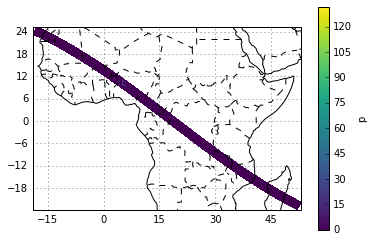

In [17]:
ax = plt.axes(projection=ccrs.PlateCarree())
da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), x='lon', y='lat')
ax.coastlines(); 
# Gridlines
xl = ax.gridlines(draw_labels=True);
xl.xlabels_top = False
xl.ylabels_right = False
# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--');

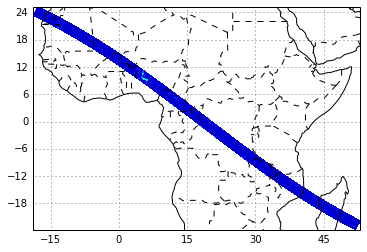

In [18]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.contourf(da['lon'], da['lat'], d['p'], transform=ccrs.PlateCarree())
ax.coastlines(); 
# Gridlines
xl = ax.gridlines(draw_labels=True);
xl.xlabels_top = False
xl.ylabels_right = False
# Countries
ax.add_feature(cartopy.feature.BORDERS, linestyle='--');